In [6]:
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import OmegaConf

In [8]:
import os
os.environ["BLISS_HOME"] = "/home/dereklh/projects/bliss/"

In [4]:
with initialize(config_path="../sdss_galaxies_vae/config", job_name="overlap"):
    cfg = compose(config_name="config")   
    print(OmegaConf.to_yaml(cfg))

mode: train
gpus: 1
paths:
  root: ${oc.env:BLISS_HOME}
  sdss: ${paths.root}/data/sdss
  data: ${paths.root}/data
  project: ${paths.root}/case_studies/sdss_galaxies_vae
  output: ${paths.project}/output
datasets:
  sdss_blended_galaxies:
    _target_: bliss.datasets.sdss_blended_galaxies.SdssBlendedGalaxies
    detection_encoder: ${models.detection_encoder}
    binary_encoder: ${models.binary}
    location_ckpt: ${paths.project}/models/sdss_detection_encoder.pt
    binary_ckpt: ${paths.project}/models/sdss_binary.pt
    sdss_dir: ${paths.sdss}
    prerender_device: cuda
    stride_factor: 0.25
  sdss_galaxies:
    _target_: bliss.datasets.galsim_galaxies.SingleGalsimGalaxies
    prior:
      _target_: bliss.datasets.galsim_galaxies.SingleGalsimGalaxyPrior
      flux_sample: pareto
      min_flux: 622.0
      max_flux: 1000000.0
      alpha: 0.47
      a_sample: gamma
      a_concentration: 0.39330758068481686
      a_loc: 0.8371888967872619
      a_scale: 4.432725319432478
      a_bu

simulated_dataset = instantiate(cfg.datasets.simulated)

In [9]:
simulated_dataset = instantiate(cfg.datasets.simulated)

In [21]:
batch_size=1
n_tiles_h=20
n_tiles_w=20
tile_catalog = simulated_dataset.sample_prior(batch_size, n_tiles_h, n_tiles_w)

In [22]:
tile_catalog.allowed_params

{'blendedness',
 'dec',
 'detection_thresholds',
 'ellips',
 'fluxes',
 'galaxy_blends',
 'galaxy_bools',
 'galaxy_fluxes',
 'galaxy_params',
 'galaxy_probs',
 'hlr',
 'lens_params',
 'lensed_galaxy_bools',
 'lensed_galaxy_probs',
 'mags',
 'matched',
 'mismatched',
 'n_source_log_probs',
 'objid',
 'ra',
 'snr',
 'star_bools',
 'star_fluxes',
 'star_log_fluxes'}

In [23]:
tile_catalog.n_sources

tensor([[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      

In [25]:
img, bg = simulated_dataset.simulate_image_from_catalog(tile_catalog)

In [26]:
img.shape

torch.Size([1, 1, 128, 128])

In [27]:
import matplotlib.pyplot as plt

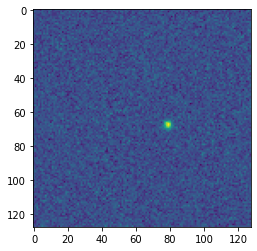

In [31]:
%matplotlib inline
plt.imshow(img[0, 0])